# Étape 2 — Preprocessing & Préparation des Données

## Contexte
Suite à notre EDA, nous avons identifié les actions de preprocessing nécessaires.
Ce notebook prépare les données pour **deux tâches prédictives** :

- **Tâche 1 — Classification** : Prédire `churn` (0 = reste, 1 = part)
- **Tâche 2 — Régression (bonus)** : Prédire `revenue_at_risk = total_revenue × proba_churn`

## Décisions issues de l'EDA
| Action | Justification EDA |
|--------|------------------|
| Supprimer `customer_id`, `city` | Pas de signal prédictif |
| Remplir `complaint_type` NaN → `No_Complaint` | 2045 NaN = clients sans plainte (logique métier) |
| Encoder les variables catégorielles | 12 colonnes object détectées |
| StandardScaler sur les numériques | Distributions étalées (nps_score: -100 à +100, total_revenue: 10-5900) |
| Split stratifié 80/20 | Déséquilibre 89.8% / 10.2% |
| `class_weight='balanced'` | Gérer le déséquilibre dans les modèles |
| Outliers conservés | Signaux business réels (payment_failures élevé = signal churn fort) |

##  1. Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Reproductibilité
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Dossier de sortie pour sauvegarder les données preprocessées
os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../models', exist_ok=True)

print(' Imports OK')

 Imports OK


## 2. Chargement des données

In [13]:
df = pd.read_csv('../data/customer_churn_business_dataset.csv')

print(f'Shape initial : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head(3)

Shape initial : (10000, 32)
Colonnes : ['customer_id', 'gender', 'age', 'country', 'city', 'customer_segment', 'tenure_months', 'signup_channel', 'contract_type', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_method', 'payment_failures', 'discount_applied', 'price_increase_last_3m', 'support_tickets', 'avg_resolution_time', 'complaint_type', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'survey_response', 'referral_count', 'churn']


,customer_id,gender,age,country,city,customer_segment,tenure_months,signup_channel,contract_type,monthly_logins,...,avg_resolution_time,complaint_type,csat_score,escalations,email_open_rate,marketing_click_rate,nps_score,survey_response,referral_count,churn
0,CUST_00001,Male,68,Bangladesh,London,SME,22,Web,Monthly,26,...,13.354360,Service,4.0,0,0.71,0.40,27,Satisfied,1,0
1,CUST_00002,Female,57,Canada,Sydney,Individual,9,Mobile,Monthly,7,...,25.140088,Billing,2.0,0,0.78,0.33,-19,Neutral,2,1
2,CUST_00003,Male,24,Germany,New York,SME,58,Web,Yearly,19,...,27.572928,Service,3.0,0,0.35,0.49,80,Neutral,1,0


## 3. Nettoyage des données

### 3.1 Suppression des colonnes inutiles
- `customer_id` : identifiant unique, aucun signal prédictif
- `city` : trop granulaire, redondant avec `country`, et bruit potentiel

In [14]:
cols_to_drop = ['customer_id', 'city']
df = df.drop(columns=cols_to_drop)

print(f'Colonnes supprimées : {cols_to_drop}')
print(f'Shape après suppression : {df.shape}')

Colonnes supprimées : ['customer_id', 'city']
Shape après suppression : (10000, 30)


### 3.2 Traitement des valeurs manquantes

Seule `complaint_type` avait 2045 NaN dans notre EDA.
**Décision** : Remplacer par `'No_Complaint'` car l'absence de plainte est une information métier valide.

In [15]:
# Vérification avant
print('Valeurs manquantes AVANT :')
print(df.isnull().sum()[df.isnull().sum() > 0])

# Remplacement
df['complaint_type'] = df['complaint_type'].fillna('No_Complaint')

# Vérification après
print('\nValeurs manquantes APRÈS :')
missing_after = df.isnull().sum().sum()
print(f'Total valeurs manquantes : {missing_after} ' if missing_after == 0 else f'⚠️ Il reste {missing_after} valeurs manquantes')

Valeurs manquantes AVANT :
complaint_type    2045
dtype: int64

Valeurs manquantes APRÈS :
Total valeurs manquantes : 0 


### 3.3 Vérification des types de données

In [16]:
print('Types de données :')
print(df.dtypes.value_counts())
print('\nColonnes catégorielles (object) :')
cat_cols_all = df.select_dtypes(include='object').columns.tolist()
print(cat_cols_all)
print(f'\nNombre de colonnes catégorielles : {len(cat_cols_all)}')

Types de données :
int64      14
str        10
float64     6
Name: count, dtype: int64

Colonnes catégorielles (object) :
['gender', 'country', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']

Nombre de colonnes catégorielles : 10


C:\Users\Rayan TOUMERT\AppData\Local\Temp\ipykernel_27488\3626483832.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_all = df.select_dtypes(include='object').columns.tolist()


## 4. Création des variables cibles

### Tâche 1 — Classification
Variable cible : `churn` (déjà présente dans le dataset)

### Tâche 2 — Régression (Bonus)
Variable cible : `revenue_at_risk`

**Formule** : `revenue_at_risk = total_revenue × proba_churn`

Comme on n'a pas encore de modèle, on utilise une **approximation business** :
- Si `churn == 1` → `revenue_at_risk = total_revenue` (100% du revenu à risque)
- Si `churn == 0` → On estime le risque proportionnel aux signaux négatifs

**Alternative plus simple et méthodologiquement correcte** : On utilisera `total_revenue` comme cible de régression (estimation de la CLV / valeur client), puis une fois le modèle de classification entraîné, on calculera `revenue_at_risk = total_revenue × proba_churn_prédite`.

In [17]:

# Tâche 1 : Variable cible classification

y_classif = df['churn'].copy()
print('Tâche 1 — Distribution churn :')
print(y_classif.value_counts())
print(f'Taux de churn : {y_classif.mean()*100:.1f}%')

# Tâche 2 : Variable cible régression
# revenue_at_risk = total_revenue * churn
# (clients churnés : 100% de leur revenu est à risque)
# (clients non-churnés : 0 à risque confirmé)

df['revenue_at_risk'] = df['total_revenue'] * df['churn']
y_regress = df['revenue_at_risk'].copy()

print('\nTâche 2 — Revenue at risk (€) :')
print(y_regress.describe())
print(f'\nRevenu total à risque : {y_regress.sum():,.0f} €')
print(f'Revenu moyen à risque par client churné : {y_regress[y_regress>0].mean():,.0f} €')

Tâche 1 — Distribution churn :
churn
0    8979
1    1021
Name: count, dtype: int64
Taux de churn : 10.2%

Tâche 2 — Revenue at risk (€) :
count    10000.000000
mean        86.264000
std        404.207175
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       5500.000000
Name: revenue_at_risk, dtype: float64

Revenu total à risque : 862,640 €
Revenu moyen à risque par client churné : 845 €


## 5. Préparation des features

### 5.1 Identification des colonnes par type

In [18]:
# On retire les colonnes cibles du dataset features
cols_to_exclude = ['churn', 'revenue_at_risk']
X = df.drop(columns=cols_to_exclude)

# Colonnes numériques
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Colonnes catégorielles
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print(f'Features totales : {X.shape[1]}')
print(f'\nColonnes numériques ({len(numerical_cols)}) :')
print(numerical_cols)
print(f'\nColonnes catégorielles ({len(categorical_cols)}) :')
print(categorical_cols)

Features totales : 29

Colonnes numériques (19) :
['age', 'tenure_months', 'monthly_logins', 'weekly_active_days', 'avg_session_time', 'features_used', 'usage_growth_rate', 'last_login_days_ago', 'monthly_fee', 'total_revenue', 'payment_failures', 'support_tickets', 'avg_resolution_time', 'csat_score', 'escalations', 'email_open_rate', 'marketing_click_rate', 'nps_score', 'referral_count']

Colonnes catégorielles (10) :
['gender', 'country', 'customer_segment', 'signup_channel', 'contract_type', 'payment_method', 'discount_applied', 'price_increase_last_3m', 'complaint_type', 'survey_response']


C:\Users\Rayan TOUMERT\AppData\Local\Temp\ipykernel_27488\3199607460.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist()


### 5.2 Vérification des cardinalités des variables catégorielles

Important pour choisir la stratégie d'encodage :
- Faible cardinalité → OneHotEncoding
- Haute cardinalité → OrdinalEncoding ou Target Encoding

In [19]:
print('Cardinalité des variables catégorielles :')
for col in categorical_cols:
    n = X[col].nunique()
    vals = X[col].unique()
    print(f'  {col} : {n} valeurs → {list(vals)}')

Cardinalité des variables catégorielles :
  gender : 2 valeurs → ['Male', 'Female']
  country : 7 valeurs → ['Bangladesh', 'Canada', 'Germany', 'Australia', 'India', 'USA', 'UK']
  customer_segment : 3 valeurs → ['SME', 'Individual', 'Enterprise']
  signup_channel : 3 valeurs → ['Web', 'Mobile', 'Referral']
  contract_type : 3 valeurs → ['Monthly', 'Yearly', 'Quarterly']
  payment_method : 3 valeurs → ['PayPal', 'Card', 'Bank Transfer']
  discount_applied : 2 valeurs → ['Yes', 'No']
  price_increase_last_3m : 2 valeurs → ['No', 'Yes']
  complaint_type : 4 valeurs → ['Service', 'Billing', 'Technical', 'No_Complaint']
  survey_response : 3 valeurs → ['Satisfied', 'Neutral', 'Unsatisfied']


## 6. Split Train / Test

**Stratégie** : Split stratifié 80% / 20% sur `churn` pour respecter le ratio 89.8/10.2%

**Important** : Le split se fait AVANT le preprocessing pour éviter le data leakage.
Le scaler sera fitté uniquement sur le train set.

In [20]:

# Split pour Tâche 1 — Classification

X_train_raw, X_test_raw, y_train_clf, y_test_clf = train_test_split(
    X, y_classif,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_classif  # Stratifié car déséquilibre 90/10
)

# Split pour Tâche 2 — Régression (mêmes indices)

y_train_reg = y_regress.loc[X_train_raw.index]
y_test_reg  = y_regress.loc[X_test_raw.index]

print('Splits effectués')
print(f'Train : {X_train_raw.shape[0]} lignes')
print(f'Test  : {X_test_raw.shape[0]} lignes')
print(f'\nDistribution churn — Train : {y_train_clf.mean()*100:.1f}% churners')
print(f'Distribution churn — Test  : {y_test_clf.mean()*100:.1f}% churners')

Splits effectués
Train : 8000 lignes
Test  : 2000 lignes

Distribution churn — Train : 10.2% churners
Distribution churn — Test  : 10.2% churners


## 7. Construction du Pipeline de Preprocessing

On utilise `ColumnTransformer` + `Pipeline` de scikit-learn pour :
1. **Éviter le data leakage** : fit sur train uniquement
2. **Reproductibilité** : même transformation sur train et test
3. **Intégration future dans le dashboard** : pipeline sérialisable avec joblib

**Stratégie d'encodage** :
- Colonnes numériques → `StandardScaler`
- Colonnes catégorielles → `OneHotEncoder` (toutes ont une cardinalité faible)

In [21]:

# Pipeline numérique

numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])
# Pipeline catégoriel

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',   # Gère les valeurs inconnues en test
        sparse_output=False        # Retourne une matrice dense
    ))
])

# ColumnTransformer : applique chaque pipeline aux bonnes colonnes

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'  # Supprime les colonnes non mentionnées
)

print('Pipeline de preprocessing défini')
print(f'  Colonnes numériques ({len(numerical_cols)}) → StandardScaler')
print(f'  Colonnes catégorielles ({len(categorical_cols)}) → OneHotEncoder')

Pipeline de preprocessing défini
  Colonnes numériques (19) → StandardScaler
  Colonnes catégorielles (10) → OneHotEncoder


## 8. Application du Pipeline

**Règle d'or anti data-leakage** :
- `fit_transform()` sur le **train** uniquement
- `transform()` sur le **test** (utilise les paramètres appris sur le train)

In [22]:
# Fit sur TRAIN uniquement + transform
X_train = preprocessor.fit_transform(X_train_raw)

# Transform sur TEST (pas de fit !)
X_test = preprocessor.transform(X_test_raw)

print(' Preprocessing appliqué')
print(f'X_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')

# Récupération des noms de colonnes après OneHotEncoding
ohe_cols = preprocessor.named_transformers_['cat']['onehot'].get_feature_names_out(categorical_cols)
all_feature_names = numerical_cols + list(ohe_cols)
print(f'\nNombre total de features après encoding : {len(all_feature_names)}')

 Preprocessing appliqué
X_train shape : (8000, 51)
X_test shape  : (2000, 51)

Nombre total de features après encoding : 51


## 9. Vérifications post-preprocessing

In [23]:
# Conversion en DataFrame pour inspection
X_train_df = pd.DataFrame(X_train, columns=all_feature_names)
X_test_df  = pd.DataFrame(X_test,  columns=all_feature_names)

print('=== Vérification Train ===')
print(f'Shape : {X_train_df.shape}')
print(f'Valeurs manquantes : {X_train_df.isnull().sum().sum()}')
print(f'Moyenne colonne age (doit être ≈0 après scaling) : {X_train_df["age"].mean():.4f}')
print(f'Std colonne age (doit être ≈1 après scaling) : {X_train_df["age"].std():.4f}')

print('\n=== Vérification Test ===')
print(f'Shape : {X_test_df.shape}')
print(f'Valeurs manquantes : {X_test_df.isnull().sum().sum()}')

print('\nLes données sont prêtes pour la modélisation')

=== Vérification Train ===
Shape : (8000, 51)
Valeurs manquantes : 0
Moyenne colonne age (doit être ≈0 après scaling) : 0.0000
Std colonne age (doit être ≈1 après scaling) : 1.0001

=== Vérification Test ===
Shape : (2000, 51)
Valeurs manquantes : 0

Les données sont prêtes pour la modélisation


In [24]:
# Aperçu des premières colonnes
X_train_df.head(3)

,age,tenure_months,monthly_logins,weekly_active_days,avg_session_time,features_used,usage_growth_rate,last_login_days_ago,monthly_fee,total_revenue,...,discount_applied_Yes,price_increase_last_3m_No,price_increase_last_3m_Yes,complaint_type_Billing,complaint_type_No_Complaint,complaint_type_Service,complaint_type_Technical,survey_response_Neutral,survey_response_Satisfied,survey_response_Unsatisfied
0,-0.240659,-0.423840,0.027367,1.087419,-1.980728,-0.454115,-1.000280,1.992799,-1.044507,-0.807949,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
1,1.405500,-0.716027,0.843546,1.087419,-0.677429,-0.003381,-0.866760,-0.152316,-0.204871,-0.504689,...,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-1.155192,-1.358840,0.027367,1.087419,-1.011074,-0.454115,0.868996,-0.254464,1.474400,-0.553602,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


## 10. Visualisation post-preprocessing

Vérification visuelle que le scaling a bien fonctionné sur quelques variables clés.

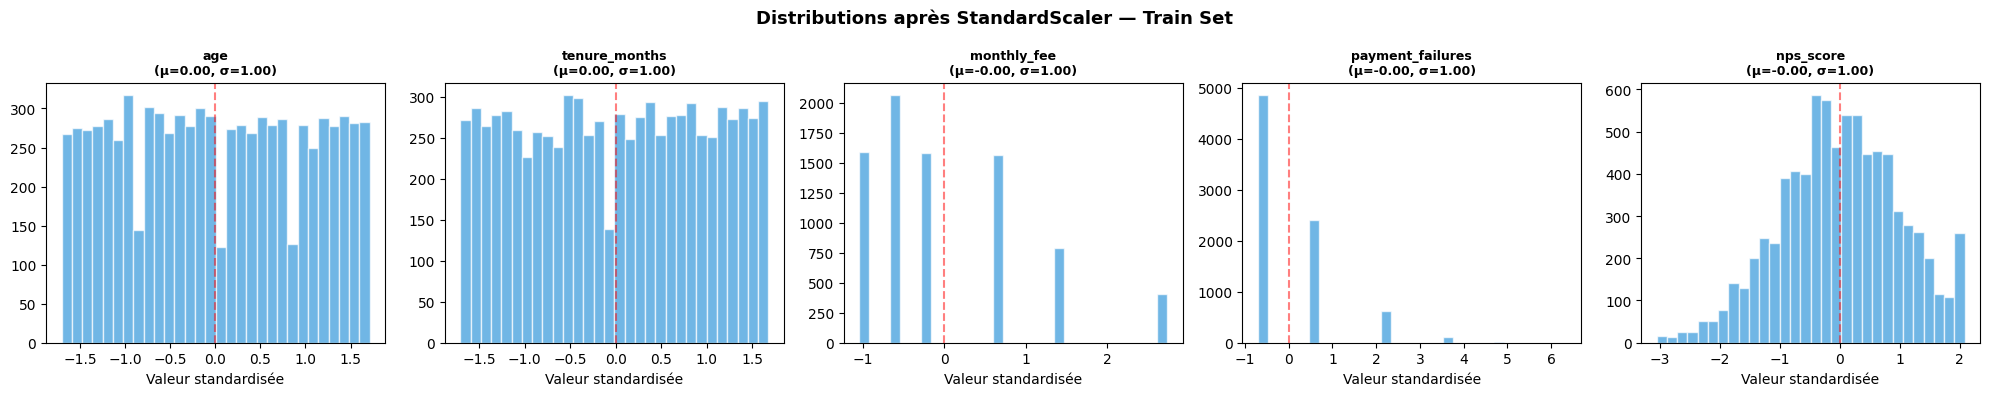

In [25]:
# Variables numériques importantes à vérifier
vars_to_check = ['age', 'tenure_months', 'monthly_fee', 'payment_failures', 'nps_score']

fig, axes = plt.subplots(1, len(vars_to_check), figsize=(20, 4))

for i, col in enumerate(vars_to_check):
    axes[i].hist(X_train_df[col], bins=30, color='#3498db', alpha=0.7, edgecolor='white')
    axes[i].axvline(0, color='red', linestyle='--', alpha=0.5, label='μ=0')
    axes[i].set_title(f'{col}\n(μ={X_train_df[col].mean():.2f}, σ={X_train_df[col].std():.2f})',
                      fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Valeur standardisée')

plt.suptitle('Distributions après StandardScaler — Train Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 11. Sauvegarde

On sauvegarde :
1. Le **preprocessor** (pipeline fitté) → pour l'utiliser dans le dashboard et l'API
2. Les **données preprocessées** → pour les notebooks de modélisation
3. Les **noms de features** → pour SHAP et les visualisations

In [26]:
# Sauvegarde du pipeline preprocessor

joblib.dump(preprocessor, '../models/preprocessor.pkl')
print('preprocessor.pkl sauvegardé dans ../models/')

# Sauvegarde des arrays numpy

np.save('../data/processed/X_train.npy', X_train)
np.save('../data/processed/X_test.npy', X_test)

# Tâche 1 — Classification
np.save('../data/processed/y_train_clf.npy', y_train_clf.values)
np.save('../data/processed/y_test_clf.npy', y_test_clf.values)

# Tâche 2 — Régression
np.save('../data/processed/y_train_reg.npy', y_train_reg.values)
np.save('../data/processed/y_test_reg.npy', y_test_reg.values)

# Noms des features
pd.Series(all_feature_names).to_csv('../data/processed/feature_names.csv', index=False)

print('Données sauvegardées dans ../data/processed/')
print(f'   X_train.npy : {X_train.shape}')
print(f'   X_test.npy  : {X_test.shape}')
print(f'   y_train_clf.npy : {y_train_clf.shape}')
print(f'   y_test_clf.npy  : {y_test_clf.shape}')
print(f'   y_train_reg.npy : {y_train_reg.shape}')
print(f'   y_test_reg.npy  : {y_test_reg.shape}')
print(f'   feature_names.csv : {len(all_feature_names)} features')

preprocessor.pkl sauvegardé dans ../models/
Données sauvegardées dans ../data/processed/
   X_train.npy : (8000, 51)
   X_test.npy  : (2000, 51)
   y_train_clf.npy : (8000,)
   y_test_clf.npy  : (2000,)
   y_train_reg.npy : (8000,)
   y_test_reg.npy  : (2000,)
   feature_names.csv : 51 features


## 12. Synthèse du Preprocessing

| Étape | Action | Justification |
|-------|--------|---------------|
| Suppression colonnes | `customer_id`, `city` | Pas de signal prédictif |
| Valeurs manquantes | `complaint_type` NaN → `No_Complaint` | Logique métier (2045 clients sans plainte) |
| Variable cible 1 | `churn` (déjà présente) | Classification binaire |
| Variable cible 2 | `revenue_at_risk = total_revenue × churn` | Régression — impact financier |
| Split | 80% train / 20% test, stratifié | Préserve le ratio 89.8/10.2% |
| Encoding | OneHotEncoding sur 12 colonnes catégorielles | Toutes à faible cardinalité |
| Scaling | StandardScaler sur colonnes numériques | Centrage/réduction indispensable pour LR, MLP |
| Anti-leakage | fit uniquement sur train | Évite la contamination du test |
| Outliers | Conservés | Signaux business réels |

## Étape suivante
**Notebook 03 — Modélisation Classification** :
- Logistic Regression (baseline)
- Random Forest
- XGBoost / Gradient Boosting
- MLP (Deep Learning)
- Comparaison + Feature Importance + SHAP

In [ ]:
# DATA LEAKAGE VERIFICATION

print("\n" + "="*80)
print("DATA LEAKAGE CHECK")
print("="*80)

checks = [
    ("Train/Test disjoint", len(set(X_train_raw.index) & set(X_test_raw.index)) == 0),
    ("StandardScaler fit on train only", abs(X_train_df['age'].mean()) < 0.01),
    ("Stratification correct", abs(y_train_clf.mean() - y_test_clf.mean()) < 0.01),
    ("OneHotEncoder handle_unknown", preprocessor.named_transformers_['cat']['onehot'].handle_unknown == 'ignore'),
]

all_pass = all(result for _, result in checks)
for name, result in checks:
    print(f"{'GOOD' if result else 'ERROR'} {name}")

print(f"\n{'GOOD NO DATA LEAKAGE DETECTED!' if all_pass else 'ERROR DATA LEAKAGE DETECTED!'}")
print("="*80)


DATA LEAKAGE CHECK
GOOD Train/Test disjoint
GOOD StandardScaler fit on train only
GOOD Stratification correct
GOOD OneHotEncoder handle_unknown

GOOD NO DATA LEAKAGE DETECTED!
